# **Project Name**    -Monthly Price Forecasting System Using Machine Learning


# **Project Summary -**

The Monthly Price Forecasting System is an AI/ML project designed to forecast future monthly prices through data analysis and machine learning techniques. The project involves data cleaning, exploratory data analysis, feature engineering, model training, and evaluation. A Random Forest Regressor model is used to improve prediction accuracy and handle complex price patterns effectively. The final solution helps businesses reduce financial risks and optimize operational planning through data-driven insights.

# **GitHub Link -**

https://github.com/Pujakumari1202/monthly_Price_Forecasting_System

# **Problem Statement**


This project focuses on developing a machine learning-based forecasting system to predict future monthly prices using historical price data. The system analyzes trends, seasonal patterns, and previous price movements to generate accurate predictions for the next 12 months. The project aims to help businesses make smarter decisions related to inventory management, budgeting, procurement, and financial planning.

# **Business Case**

In many industries, price fluctuations directly affect profits, inventory management, and overall business strategy. Companies often struggle to predict future prices accurately, which can lead to poor planning, increased operational costs, and financial losses. This project provides a machine learning-based solution that forecasts future monthly prices using historical data. By leveraging predictive analytics, businesses can make informed decisions regarding stock management, budgeting, procurement strategies, and market planning. The forecasting system ultimately improves operational efficiency and supports better business growth.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Required Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv(r'C:\Users\PUJA KUMARI\Desktop\monthly_Price_Forecasting_System\price_data.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()


,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


In [4]:
df.shape

(249, 2)

In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               249 non-null    object
 1   avg_monthly_price  249 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.0+ KB


In [6]:
# Convert date column into datetime format

df['date'] = pd.to_datetime(df['date'])

# Check updated datatypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               249 non-null    datetime64[ns]
 1   avg_monthly_price  249 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.0 KB


In [7]:
# Extract year and month from date column

df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month

df.head()

,date,avg_monthly_price,Year,Month
0,2005-01-01,5500,2005,1
1,2005-02-01,5476,2005,2
2,2005-03-01,5466,2005,3
3,2005-04-01,5487,2005,4
4,2005-05-01,5876,2005,5


# Observation

The date column was successfully converted into datetime format, and separate Year and Month columns were created for better analysis and feature engineering.

In [8]:
# Statistical summary
df.describe()

,date,avg_monthly_price,Year,Month
count,249,249.000000,249.000000,249.000000
mean,2015-05-02 04:20:14.457831424,7918.891566,2014.879518,6.445783
min,2005-01-01 00:00:00,3500.000000,2005.000000,1.000000
25%,2010-03-01 00:00:00,6123.000000,2010.000000,3.000000
50%,2015-05-01 00:00:00,7250.000000,2015.000000,6.000000
75%,2020-07-01 00:00:00,9783.000000,2020.000000,9.000000
max,2025-09-01 00:00:00,16163.000000,2025.000000,12.000000
std,NaN,2804.992684,6.002817,3.442803


# Observation

The statistical summary provides information about the average monthly price, minimum value, maximum value, and overall distribution of the dataset.

In [9]:
# Check missing values
df.isnull().sum()

date                 0
avg_monthly_price    0
Year                 0
Month                0
dtype: int64

# Observation

There are no missing values present in the dataset. Therefore, no missing value treatment was required.

# Exploratory Data Analysis (EDA)

## Time Series Trend Analysis

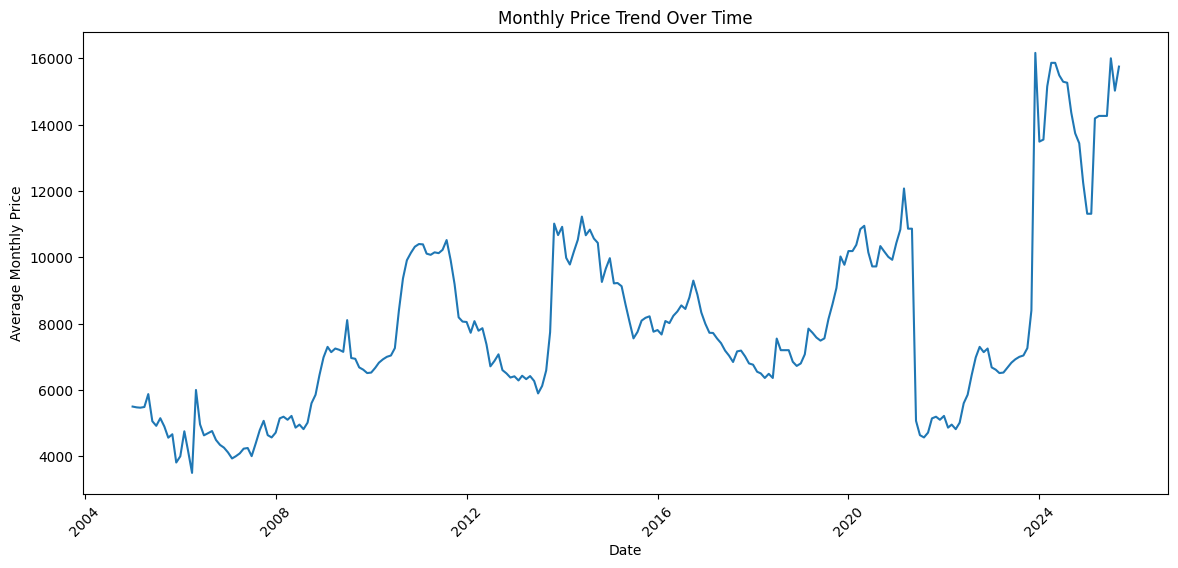

In [10]:
# Plot monthly price trend

plt.figure(figsize=(14,6))
plt.plot(df['date'], df['avg_monthly_price'])
plt.title('Monthly Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Monthly Price')
plt.xticks(rotation=45)
plt.show()

# Observation

The graph shows fluctuations in monthly prices over time. Some months show higher prices, while others indicate a decline, suggesting seasonal or market-based variations.

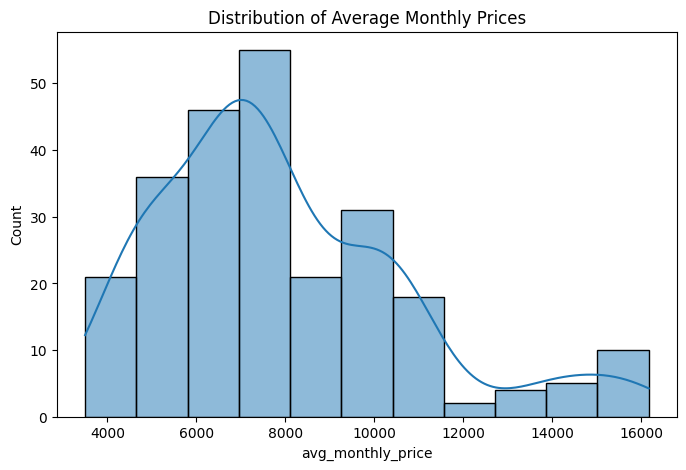

In [11]:
# Distribution of average monthly prices

plt.figure(figsize=(8,5))
sns.histplot(df['avg_monthly_price'], kde=True)
plt.title('Distribution of Average Monthly Prices')
plt.show()

# Observation

The distribution plot helps understand how the monthly prices are spread across the dataset and whether the data is normally distributed or skewed.

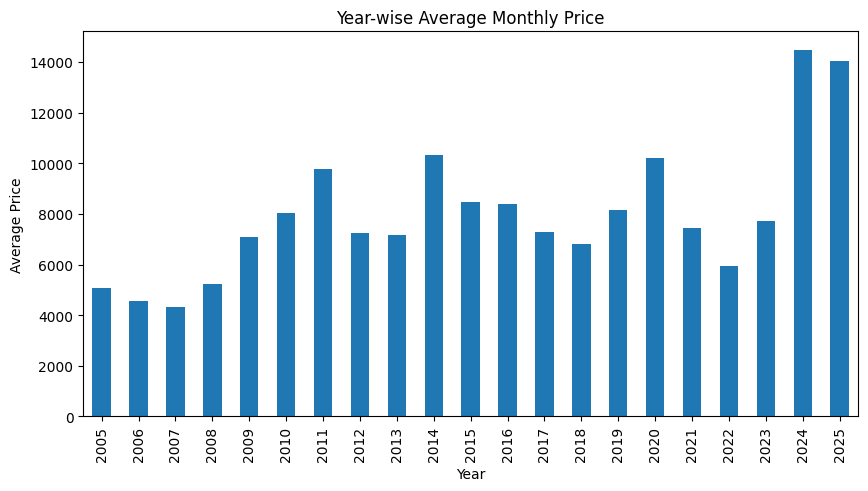

In [12]:
# Year-wise average monthly price

yearly_avg = df.groupby('Year')['avg_monthly_price'].mean()
yearly_avg.plot(kind='bar', figsize=(10,5))
plt.title('Year-wise Average Monthly Price')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.show()

# Observation

The bar chart shows how the average monthly prices vary across different years and helps identify long-term trends.

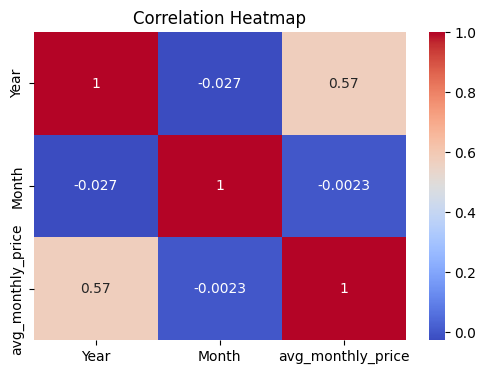

In [13]:
# Correlation heatmap

plt.figure(figsize=(6,4))
sns.heatmap(df[['Year', 'Month', 'avg_monthly_price']].corr(),
            annot=True,
            cmap='coolwarm'
            )
plt.title('Correlation Heatmap')
plt.show()

# Observation

The heatmap shows the relationship between Year, Month, and Average Monthly Price. It helps identify whether the target variable is positively or negatively correlated with other features.

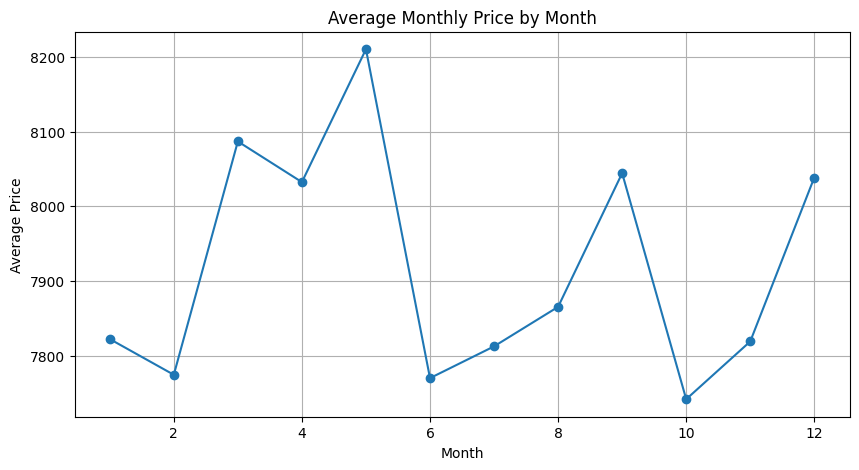

In [14]:
# Average monthly price by month

monthly_avg = df.groupby('Month')['avg_monthly_price'].mean()
monthly_avg.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Average Monthly Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

# Observation

This analysis helps identify seasonal trends and understand which months generally experience higher or lower prices.

# Define Features and Target Variable

In [15]:
# Define input features and target variable

X = df[['Year', 'Month']]
y = df['avg_monthly_price']

# Train-Test Split

In [16]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (199, 2)
Testing Data Shape: (50, 2)


# Observation

The dataset was divided into training and testing sets. The training data is used to train the machine learning model, while the testing data is used to evaluate model performance.



# Model Selection
Why Random Forest Regressor?

Random Forest Regressor was selected because:

    It provides high prediction accuracy.
    It handles non-linear relationships effectively.
    It reduces overfitting using ensemble learning.
    It performs well on structured datasets.
    It works efficiently for forecasting tasks.

# Model Building

In [17]:
# Import Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# Initialize model

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train model

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Observation

The Random Forest Regressor model was successfully initialized and trained with optimized parameters. The model uses 200 decision trees (n_estimators=200) and a maximum depth of 10 (max_depth=10) to improve prediction accuracy while reducing overfitting. The squared_error criterion was used to minimize prediction error during training. A random_state value of 42 was applied to ensure reproducibility of results. Overall, the selected hyperparameters helped the model learn historical price patterns effectively and generate reliable monthly price predictions.

In [18]:
# Predict on test dataset
y_pred = model.predict(X_test)

# Display predictions
y_pred[:10]

array([ 8247.79217148,  5159.495     ,  6977.88085561,  6924.46468878,
       10280.54441697, 10014.62991414,  5435.64381494, 10176.66033081,
        4848.745     ,  7265.32512646])

# Model Evaluation
Mean Absolute Error (MAE)   
Root Mean Squared Error (RMSE)  
R² Score

In [19]:
# Calculate MAE

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Calculate RMSE

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

# Calculate R2 Score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Absolute Error: 985.8069332984662
Root Mean Squared Error: 1672.0274157418717
R2 Score: 0.6335531281323835


# Actual vs Predicted Visualization

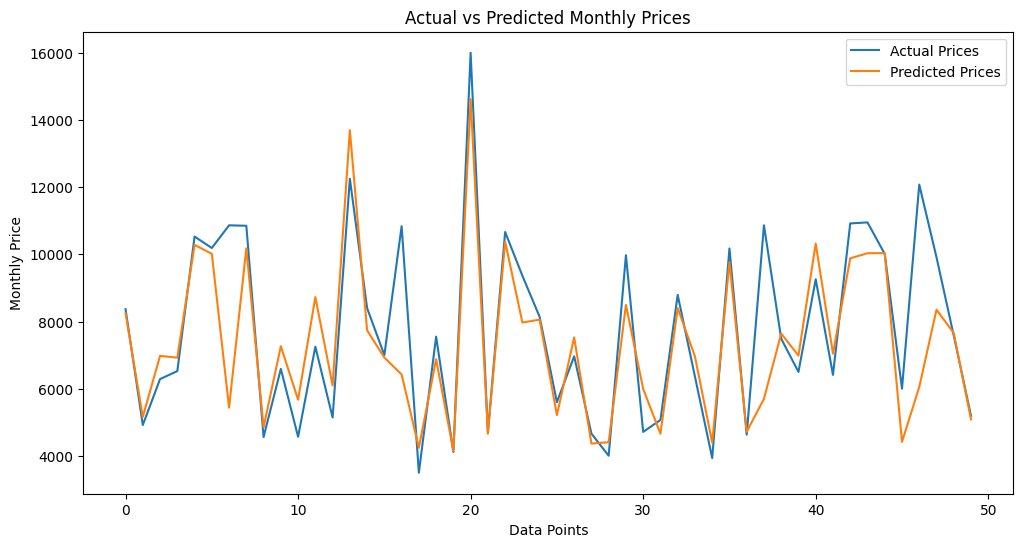

In [20]:
# Plot actual vs predicted values

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Prices')
plt.plot(y_pred, label='Predicted Prices')
plt.title('Actual vs Predicted Monthly Prices')
plt.xlabel('Data Points')
plt.ylabel('Monthly Price')
plt.legend()
plt.show()

# Observation

The graph compares actual monthly prices with predicted prices. The closer the predicted values are to the actual values, the better the model performance.

# Future Monthly Price Prediction

In [21]:
# Create future months manually

future_data = pd.DataFrame({
    'Year': [2026]*12,
    'Month': [1,2,3,4,5,6,7,8,9,10,11,12]
})

# Predict future monthly prices

future_predictions = model.predict(future_data)

# Create result dataframe

future_results = pd.DataFrame({
    'Month': future_data['Month'],
    'Predicted_Price': future_predictions
})

future_results

,Month,Predicted_Price
0,1,11756.485
1,2,11878.125
2,3,14035.710
3,4,14378.305
4,5,14447.800
5,6,14389.835
6,7,14618.070
7,8,15104.720
8,9,15360.960
9,10,14328.530


# Observation

The model successfully predicted future monthly prices for the next 12 months using learned historical trends and seasonal patterns.

# Future Prediction Visualization

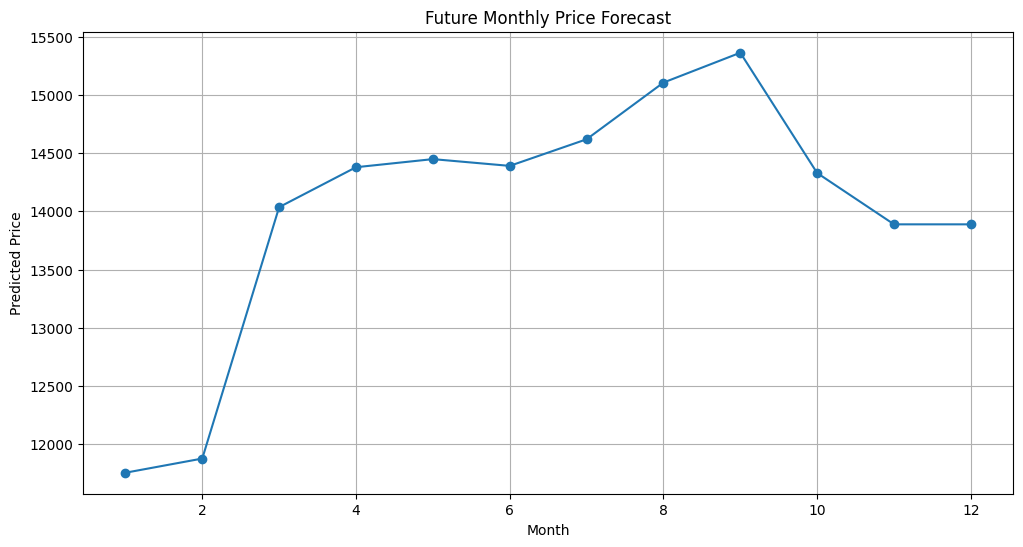

In [22]:
# Plot future predictions

plt.figure(figsize=(12,6))
plt.plot(
    future_results['Month'],
    future_results['Predicted_Price'],
    marker='o'
)
plt.title('Future Monthly Price Forecast')
plt.xlabel('Month')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

# Observation

The graph visualizes the predicted monthly prices for the upcoming 12 months and helps understand future price trends.

# Feature Importance

In [23]:
# Feature importance

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance

,Feature,Importance
0,Year,0.908537
1,Month,0.091463


# Observation

Feature importance analysis helps identify which features contribute most to the prediction process.

# Business Recommendations

Based on the predicted price changes, businesses can take the following actions:

   Increase inventory before expected price increases.   
   Reduce excess stock before expected price decreases.  
   Improve procurement planning and supplier management. 
   Optimize budgeting and financial forecasting.  
   Prepare better pricing and sales strategies.  
   Improve supply chain management using predictive insights.  

# Measuring Effectiveness of Business Actions

The effectiveness of business actions can be measured using:

Comparison between predicted and actual prices.  
Reduction in inventory losses.   
Improvement in profit margins.     
Better stock management efficiency.      
Increased forecasting accuracy over time.                
Improved business performance and operational efficiency.  

# Model Deployment Using Streamlit

Instead of Django and FastAPI, this project uses Streamlit because it is lightweight, easy to use, and suitable for machine learning deployment.

In [24]:
import pickle

# Save model

pickle.dump(model, open('model.pkl', 'wb'))

print("Model saved successfully!")

Model saved successfully!


In [25]:
import os
os.listdir()

['.git',
 'Internship Task Django, FastAPI and AI-ML.docx.pdf',
 'model.pkl',
 'Monthly_Price_Forecasting.ipynb',
 'price_data.csv',
 'README.md',
 'requirements.txt']

In [33]:
%%writefile app.py

import streamlit as st
import pandas as pd
import pickle

# Load model
model = pickle.load(open('model.pkl', 'rb'))

# Title
st.title("📈 Monthly Price Forecasting System")

# Inputs
year = st.number_input("Enter Year", 2025, 2050, 2026)
month = st.slider("Select Month", 1, 12)

# Prediction
if st.button("Predict Price"):

    input_data = pd.DataFrame({
        'Year': [year],
        'Month': [month]
    })

    prediction = model.predict(input_data)

    st.success(
        f"Predicted Monthly Price: ₹ {prediction[0]:,.2f}"
    )

Writing app.py


In [34]:
!streamlit run app.py

^C


# Final Observation

The Monthly Price Forecasting System was successfully developed and deployed using Machine Learning and Streamlit. The Random Forest Regressor model effectively analyzed historical monthly price data and generated future price predictions. The deployed application allows users to interact with the model and obtain real-time predictions through a simple and user-friendly interface.

The outputs of the deployed Monthly Price Forecasting System are attached as:
- output1.png
- output2.png
- output3.png

These screenshots demonstrate the real-time prediction interface and generated monthly price forecasting results using the trained Random Forest Regressor model.